In [ ]:
# ── CELL 1: Imports ──────────────────────────────────────────────────────────
import sys, os, json, warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

from utils.config import (
    TARGET_COL, ID_COL,
    NUMERICAL_FEATURES, CATEGORICAL_FEATURES,
    PIPELINE_PATH, SHAP_EXPLAINER_PATH,
    FEATURE_IMPORTANCE_PATH, FEATURE_ORDER_FILE,
    MODEL_METADATA_PATH,
    RANDOM_STATE, TEST_SIZE, TOP_SHAP_FEATURES,
    MODEL_CANDIDATES
)

print("✅ All imports successful")
print(f"   Python  : {sys.version.split()[0]}")

ImportError: cannot import name 'MODEL_METADATA_PATH' from 'utils.config' (c:\Users\NI\churn_project\utils\config.py)

In [ ]:
# ── CELL 2: Load Data ─────────────────────────────────────────────────────────
DATA_PATH = "../data/E Commerce Dataset.xlsx"

df_raw = pd.read_excel(DATA_PATH, sheet_name="E Comm")
print(f"✅ Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

✅ Dataset loaded: 5630 rows × 20 columns


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [ ]:
# ── CELL 3: EDA Overview ──────────────────────────────────────────────────────
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df_raw.info()

print("\n" + "=" * 60)
print("NULL VALUES (columns with missing data)")
print("=" * 60)
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
null_df = null_pct[null_pct > 0].reset_index()
null_df.columns = ["Column", "Missing %"]
print(null_df.to_string(index=False))

print("\n" + "=" * 60)
print("CHURN DISTRIBUTION")
print("=" * 60)
churn_counts = df_raw[TARGET_COL].value_counts()
print(churn_counts.rename({0: "Retained (0)", 1: "Churned (1)"}))
print(f"\nOverall Churn Rate : {churn_counts[1]/len(df_raw)*100:.2f}%")
print(f"Class Imbalance    : {churn_counts[0]/churn_counts[1]:.1f}:1  (retained:churned)")

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  Numbe

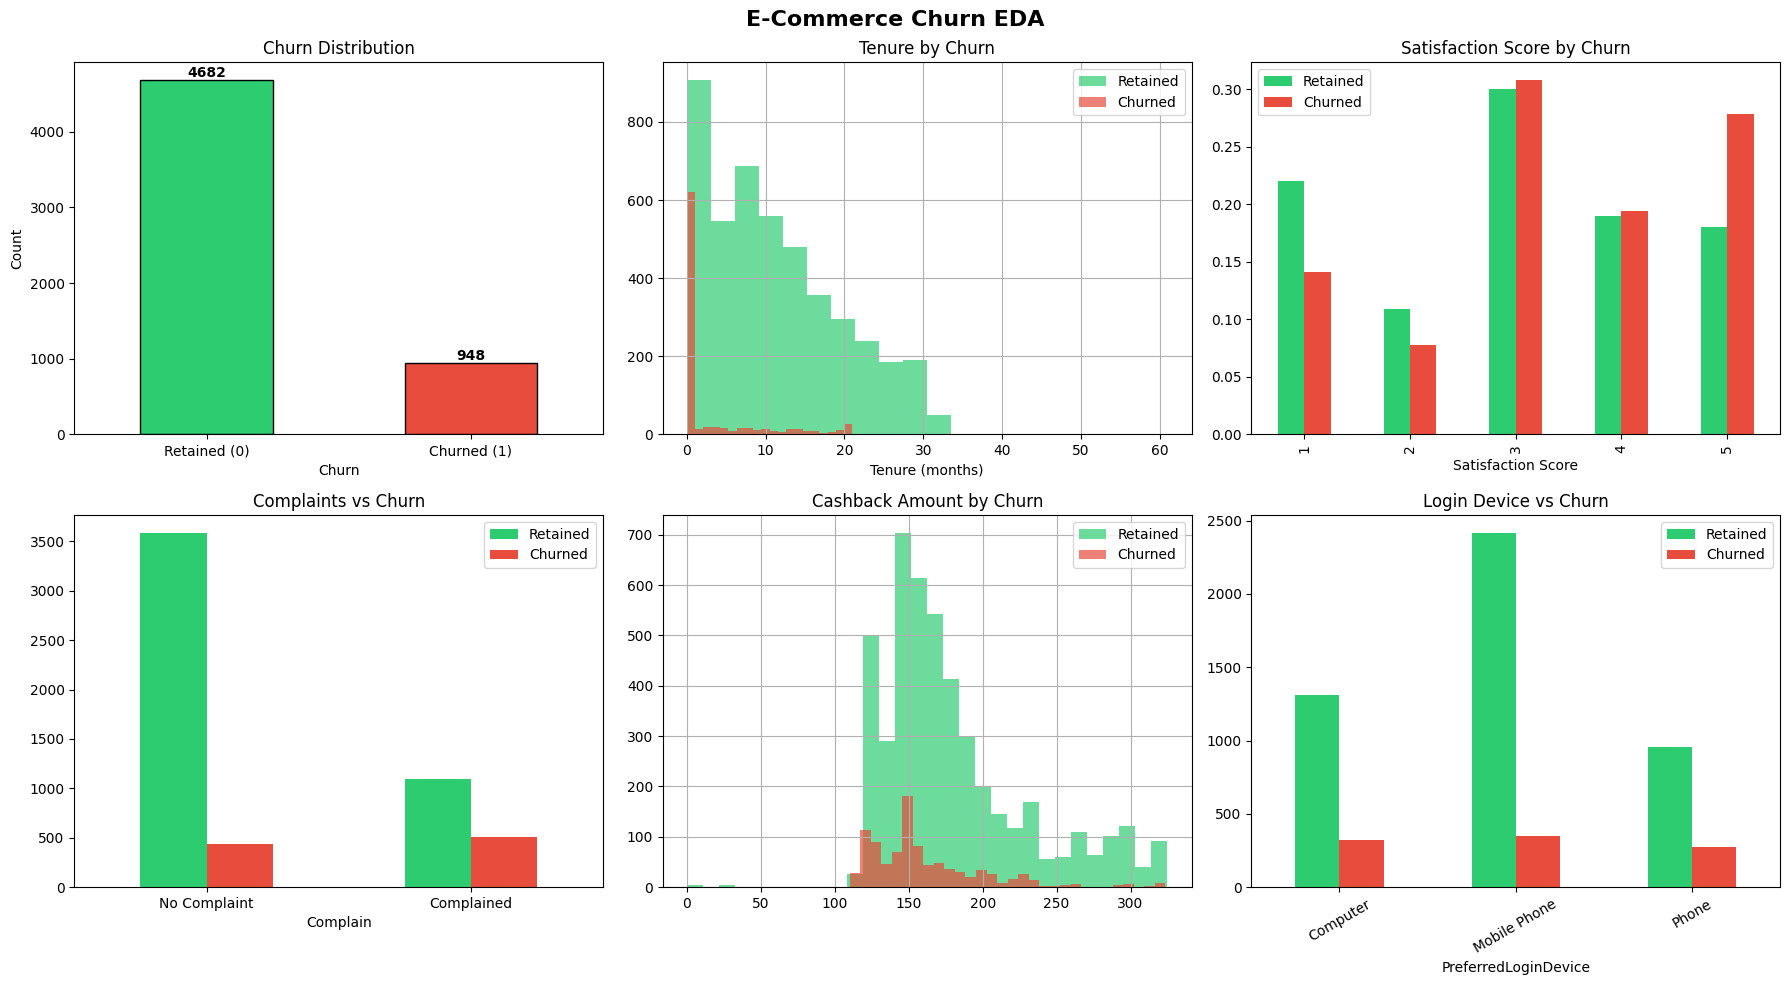

✅ EDA plots saved to artifacts/eda_overview.png


In [ ]:
# ── CELL 4: EDA Visualizations ────────────────────────────────────────────────
os.makedirs("../artifacts", exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("E-Commerce Churn — Exploratory Data Analysis",
             fontsize=16, fontweight='bold', y=1.01)

COLORS = {0: "#2ecc71", 1: "#e74c3c"}

# 1. Churn distribution
ax = axes[0, 0]
bars = ax.bar(["Retained (0)", "Churned (1)"],
               [churn_counts[0], churn_counts[1]],
               color=[COLORS[0], COLORS[1]], edgecolor='black')
ax.set_title("Churn Distribution")
ax.set_ylabel("Count")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 30,
            f'{int(b.get_height()):,}', ha='center', fontweight='bold')

# 2. Tenure distribution by churn
ax = axes[0, 1]
for label, grp in df_raw.groupby(TARGET_COL):
    grp['Tenure'].dropna().hist(ax=ax, alpha=0.7, bins=25,
                                 color=COLORS[label],
                                 label=f'{"Retained" if label==0 else "Churned"}')
ax.set_title("Tenure Distribution by Churn")
ax.set_xlabel("Tenure (months)")
ax.legend()

# 3. SatisfactionScore vs Churn
ax = axes[0, 2]
sat_data = df_raw.groupby([TARGET_COL, 'SatisfactionScore']).size().unstack(0)
sat_data.rename(columns={0:"Retained", 1:"Churned"}).plot(
    kind='bar', ax=ax, color=[COLORS[0], COLORS[1]], edgecolor='black')
ax.set_title("Satisfaction Score vs Churn")
ax.set_xlabel("Satisfaction Score (1–5)")
ax.tick_params(axis='x', rotation=0)

# 4. Complain vs Churn
ax = axes[1, 0]
comp_data = df_raw.groupby([TARGET_COL, 'Complain']).size().unstack(0)
comp_data.rename(columns={0:"Retained", 1:"Churned"}).plot(
    kind='bar', ax=ax, color=[COLORS[0], COLORS[1]], edgecolor='black')
ax.set_title("Complaints vs Churn")
ax.set_xticklabels(["No Complaint", "Complained"], rotation=0)

# 5. CashbackAmount vs Churn
ax = axes[1, 1]
for label, grp in df_raw.groupby(TARGET_COL):
    grp['CashbackAmount'].hist(ax=ax, alpha=0.7, bins=30,
                                color=COLORS[label],
                                label=f'{"Retained" if label==0 else "Churned"}')
ax.set_title("Cashback Amount Distribution by Churn")
ax.set_xlabel("Cashback Amount")
ax.legend()

# 6. PreferredLoginDevice
ax = axes[1, 2]
dev_data = df_raw.groupby([TARGET_COL, 'PreferredLoginDevice']).size().unstack(0)
dev_data.rename(columns={0:"Retained", 1:"Churned"}).plot(
    kind='bar', ax=ax, color=[COLORS[0], COLORS[1]], edgecolor='black')
ax.set_title("Login Device vs Churn")
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("../artifacts/eda_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA overview saved → artifacts/eda_overview.png")

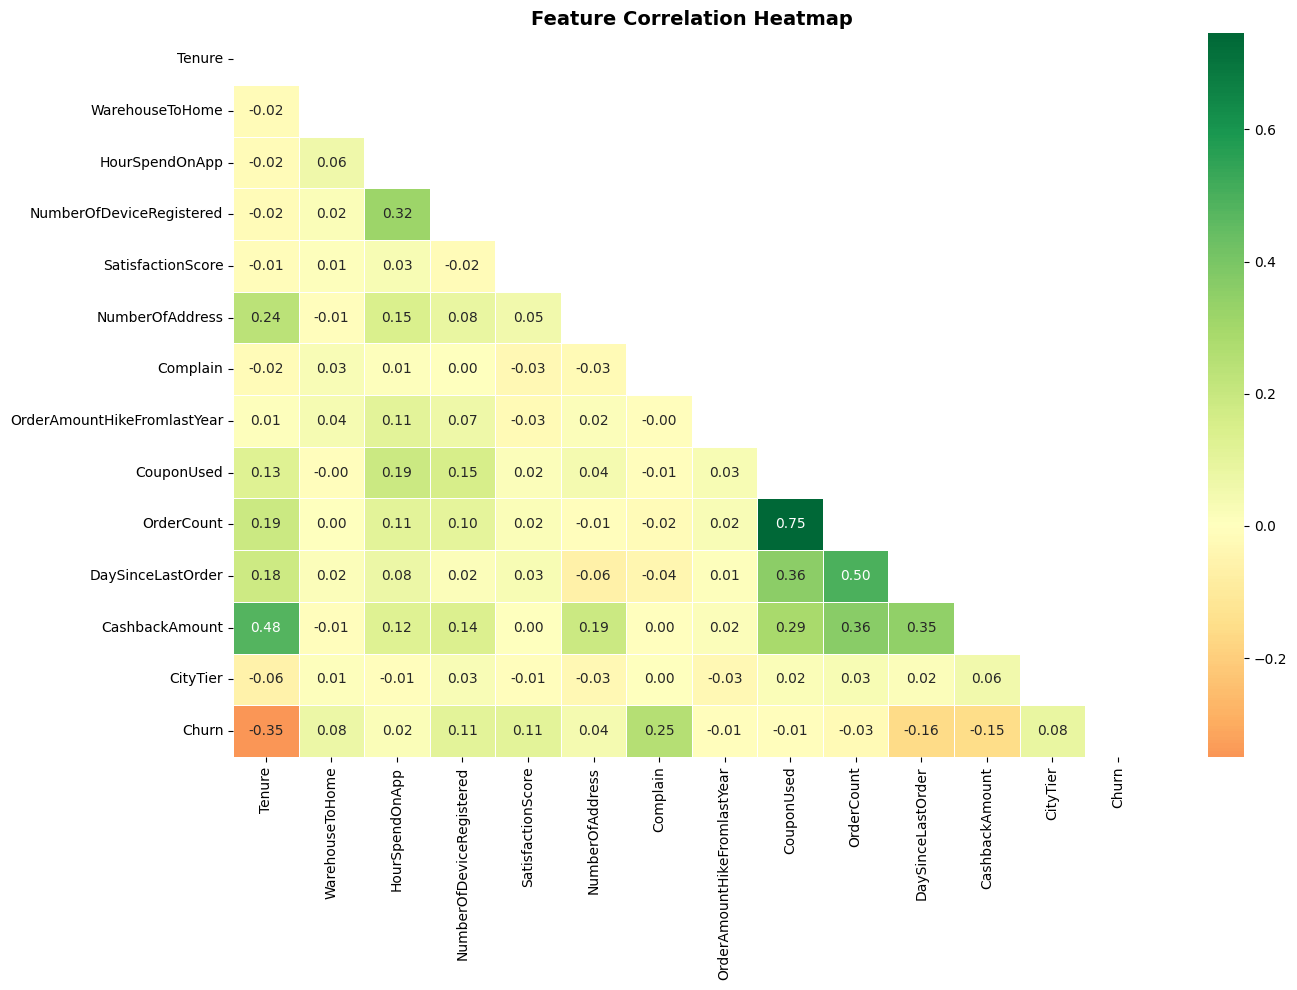

✅ Correlation heatmap saved


In [ ]:
# ── CELL 5: Correlation Heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
corr = df_raw[NUMERICAL_FEATURES + [TARGET_COL]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, ax=ax, linewidths=0.5,
            annot_kws={"size": 9})
ax.set_title("Numerical Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../artifacts/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation heatmap saved → artifacts/correlation_heatmap.png")

In [ ]:
# ── CELL 6: Preprocessor + All 3 Model Pipelines ─────────────────────────────

# --- Prepare features and target ---
df = df_raw.copy().drop(columns=[ID_COL])
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Sanity checks
missing_num = set(NUMERICAL_FEATURES) - set(X.columns)
missing_cat = set(CATEGORICAL_FEATURES) - set(X.columns)
assert not missing_num, f"Missing numerical features in dataset: {missing_num}"
assert not missing_cat, f"Missing categorical features in dataset: {missing_cat}"

# --- Stratified train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f"✅ Split complete")
print(f"   Train : {X_train.shape[0]:,} rows | Churn rate: {y_train.mean()*100:.2f}%")
print(f"   Test  : {X_test.shape[0]:,}  rows | Churn rate: {y_test.mean()*100:.2f}%")

# --- Class imbalance ratio (for XGBoost) ---
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"\n   Class ratio (neg/pos): {scale_pos_weight:.2f}  → used as XGBoost scale_pos_weight")

# ─────────────────────────────────────────────────────────────
# Shared preprocessor (identical across all 3 pipelines)
# ─────────────────────────────────────────────────────────────
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # fill nulls with median
    ("scaler",  StandardScaler()),                   # z-score normalisation
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # fill nulls with mode
    ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, NUMERICAL_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
], remainder="drop")

# ─────────────────────────────────────────────────────────────
# MODEL 1: Logistic Regression
# ─────────────────────────────────────────────────────────────
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=0.1,                      # regularisation (smaller = stronger)
        max_iter=1000,
        class_weight="balanced",    # handles class imbalance
        solver="lbfgs",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ))
])

# ─────────────────────────────────────────────────────────────
# MODEL 2: Random Forest
# ─────────────────────────────────────────────────────────────
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=4,
        class_weight="balanced",    # handles class imbalance
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ))
])

# ─────────────────────────────────────────────────────────────
# MODEL 3: XGBoost
# ─────────────────────────────────────────────────────────────
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,  # handles class imbalance
        eval_metric="auc",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    ))
])

all_pipelines = {
    "LogisticRegression": lr_pipeline,
    "RandomForest":       rf_pipeline,
    "XGBoost":            xgb_pipeline,
}

print("\n✅ All 3 model pipelines built")
print("   Preprocessor: median impute + z-score (numerical)")
print("                 mode impute  + OHE     (categorical)")

✅ Train: (4504, 18) | Test: (1126, 18)
   Train churn rate: 16.83%
   Test  churn rate: 16.87%
✅ Preprocessor built


In [ ]:
# ── CELL 7: 5-Fold CV Comparison — All 3 Models ───────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}   # { model_name: {"scores": [...], "mean": float, "std": float} }

print("⏳ Running 5-fold Stratified CV for all 3 models...\n")
print(f"{'Model':<22} {'CV AUC (mean)':<18} {'CV AUC (std)':<15} {'Min':<10} {'Max'}")
print("-" * 75)

for name, pipeline in all_pipelines.items():
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv, scoring="roc_auc", n_jobs=-1
    )
    cv_results[name] = {
        "scores": scores.tolist(),
        "mean":   float(scores.mean()),
        "std":    float(scores.std()),
        "min":    float(scores.min()),
        "max":    float(scores.max()),
    }
    print(f"{name:<22} {scores.mean():.4f}             ±{scores.std():.4f}         "
          f"{scores.min():.4f}    {scores.max():.4f}")

# ── Select best model by mean CV AUC ──────────────────────────────────────────
best_model_name = max(cv_results, key=lambda k: cv_results[k]["mean"])
best_pipeline   = all_pipelines[best_model_name]

print("\n" + "=" * 75)
print(f"🏆  Best model: {best_model_name}  "
      f"(CV AUC = {cv_results[best_model_name]['mean']:.4f})")
print("=" * 75)

# ── Bar chart: CV AUC comparison ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
model_names = list(cv_results.keys())
means  = [cv_results[m]["mean"] for m in model_names]
stds   = [cv_results[m]["std"]  for m in model_names]
colors = ["#3498db", "#2ecc71", "#e74c3c"]
highlight = ["#f39c12" if m == best_model_name else c
             for m, c in zip(model_names, colors)]

bars = ax.bar(model_names, means, yerr=stds, capsize=6,
              color=highlight, edgecolor="black", linewidth=1.2)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("ROC-AUC Score", fontsize=12)
ax.set_title("5-Fold CV AUC Comparison — All 3 Models\n(★ = selected best)",
             fontsize=13, fontweight='bold')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline')

for bar, mean, name in zip(bars, means, model_names):
    label = f"{mean:.4f}"
    if name == best_model_name:
        label = "★ " + label
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008,
            label, ha='center', va='bottom',
            fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig("../artifacts/cv_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ CV comparison chart saved → artifacts/cv_comparison.png")

# ── Box plot: per-fold AUC distribution ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
all_scores = [cv_results[m]["scores"] for m in model_names]
bp = ax.boxplot(all_scores, labels=model_names, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("ROC-AUC Score", fontsize=12)
ax.set_title("Per-Fold AUC Distribution (5-Fold CV)", fontsize=13, fontweight='bold')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig("../artifacts/cv_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ CV boxplot saved → artifacts/cv_boxplot.png")

XGBoost scale_pos_weight: 4.94

⏳ Running 5-fold CV for Random Forest...
   RF  AUC: 0.9516 ± 0.0118
⏳ Running 5-fold CV for XGBoost...
   XGB AUC: 0.9720 ± 0.0063

🏆 Best model selected: XGBoost
⏳ Fitting XGBoost on full training set...
✅ Training complete


TEST SET EVALUATION — XGBoost
              precision    recall  f1-score   support

    Retained       1.00      0.98      0.99       936
     Churned       0.91      0.99      0.95       190

    accuracy                           0.98      1126
   macro avg       0.95      0.98      0.97      1126
weighted avg       0.98      0.98      0.98      1126

ROC-AUC Score: 0.9977


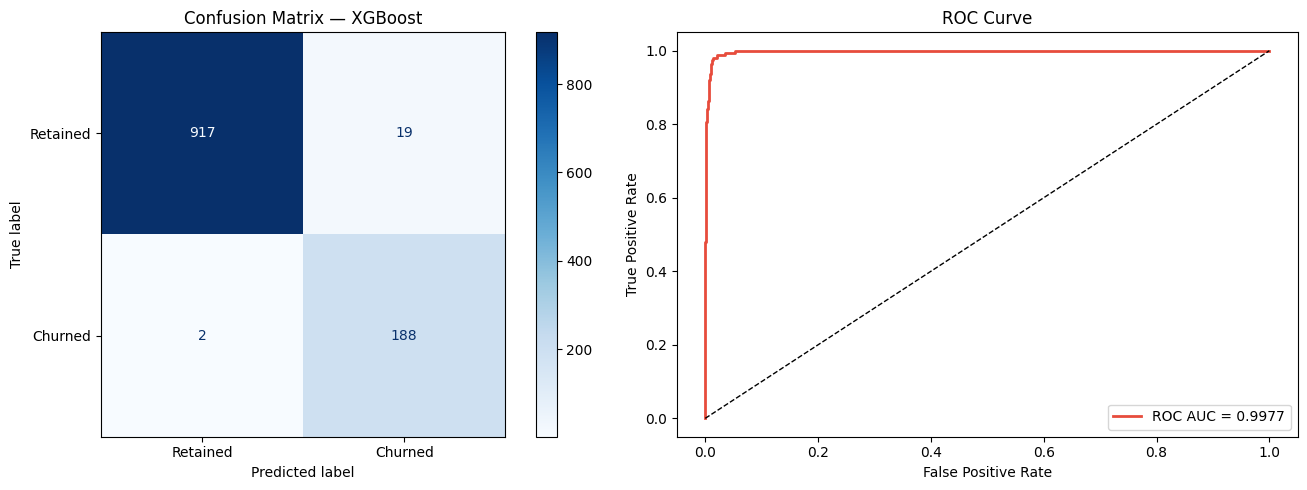

✅ Evaluation plots saved to artifacts/model_evaluation.png


In [ ]:
# ── CELL 8: Fit Best Model on Full Train Set + Evaluate on Test ───────────────
print(f"⏳ Fitting {best_model_name} on full training set ({X_train.shape[0]:,} rows)...")
best_pipeline.fit(X_train, y_train)
print("✅ Fit complete\n")

y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_prob)

print("=" * 60)
print(f"TEST SET EVALUATION — {best_model_name}")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))
print(f"ROC-AUC on test set: {test_auc:.4f}")

# ── Confusion Matrix + ROC Curve ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Test Set Evaluation — {best_model_name}", fontsize=14, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Retained", "Churned"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2.5,
             label=f'AUC = {test_auc:.4f}')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].set_title("ROC Curve")
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig("../artifacts/model_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation plots saved → artifacts/model_evaluation.png")

In [ ]:
# ── CELL 9: ROC Curves — All 3 Models on Test Set ────────────────────────────
# Fit the other two models on train set to get their test ROC curves
fig, ax = plt.subplots(figsize=(9, 7))
roc_colors = {
    "LogisticRegression": "#3498db",
    "RandomForest":       "#2ecc71",
    "XGBoost":            "#e74c3c",
}

for name, pipeline in all_pipelines.items():
    if name != best_model_name:
        pipeline.fit(X_train, y_train)   # fit the non-selected ones too for comparison
    prob = pipeline.predict_proba(X_test)[:, 1]
    auc  = roc_auc_score(y_test, prob)
    fpr_, tpr_, _ = roc_curve(y_test, prob)
    lw  = 3.0 if name == best_model_name else 1.5
    ls  = "-" if name == best_model_name else "--"
    label = f"{name}  AUC={auc:.4f}"
    if name == best_model_name:
        label += "  ★ selected"
    ax.plot(fpr_, tpr_, color=roc_colors[name],
            linewidth=lw, linestyle=ls, label=label)

ax.plot([0,1],[0,1], 'k:', linewidth=1, label='Random baseline')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve Comparison — All 3 Models (Test Set)",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../artifacts/roc_all_models.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ All-model ROC curve saved → artifacts/roc_all_models.png")

✅ Feature order saved: 34 features
First 5: ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore']
Last  5: ['PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [ ]:
# ── CELL 10: Extract + Save Exact Feature Order ────────────────────────────────
preprocessor_fitted = best_pipeline.named_steps["preprocessor"]
ohe = preprocessor_fitted.named_transformers_["cat"].named_steps["ohe"]
ohe_feature_names   = ohe.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feature_names   = NUMERICAL_FEATURES + ohe_feature_names

with open(f"../{FEATURE_ORDER_FILE}", "w") as f:
    json.dump(all_feature_names, f, indent=2)

print(f"✅ Feature order saved: {len(all_feature_names)} total features")
print(f"   Numerical : {len(NUMERICAL_FEATURES)} features")
print(f"   After OHE : {len(ohe_feature_names)} features (from {len(CATEGORICAL_FEATURES)} categorical cols)")
print(f"\n   First 5 : {all_feature_names[:5]}")
print(f"   Last  5 : {all_feature_names[-5:]}")

⏳ Building SHAP TreeExplainer...
✅ SHAP values computed: (1126, 34)
✅ Feature importance saved

Top 10 features by SHAP importance:
   1. Tenure                                   1.9148
   2. Complain                                 0.8130
   3. CashbackAmount                           0.5786
   4. NumberOfAddress                          0.5641
   5. DaySinceLastOrder                        0.4218
   6. SatisfactionScore                        0.3838
   7. WarehouseToHome                          0.3700
   8. PreferedOrderCat_Laptop & Accessory      0.3426
   9. CityTier                                 0.3358
  10. MaritalStatus_Single                     0.3354


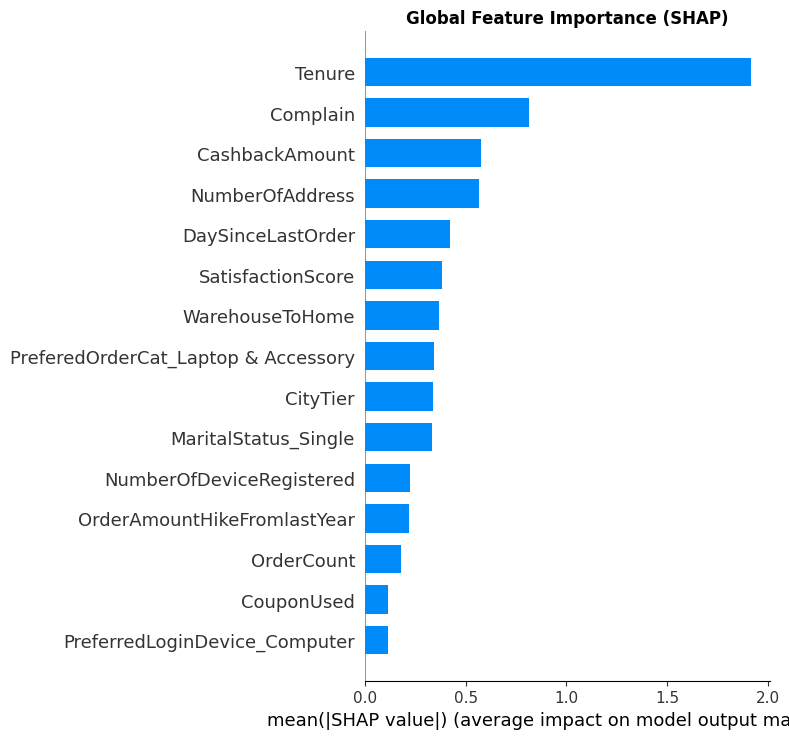

✅ SHAP bar plot saved


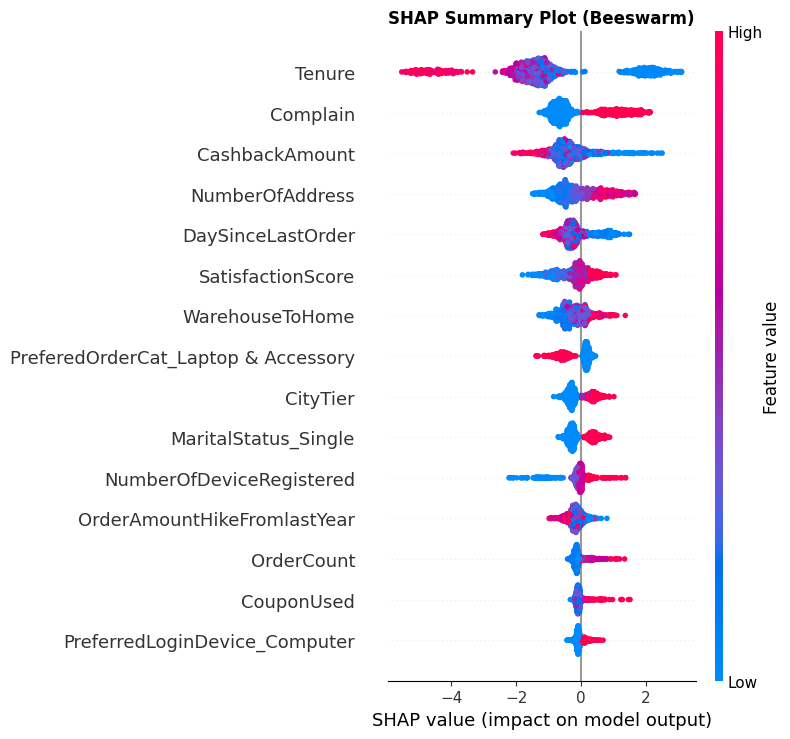

✅ SHAP beeswarm plot saved


In [ ]:
# ── CELL 11: SHAP Explainability ──────────────────────────────────────────────
# Transform test set through the fitted preprocessor
X_test_transformed = preprocessor_fitted.transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

classifier = best_pipeline.named_steps["classifier"]

print(f"⏳ Building SHAP TreeExplainer for {best_model_name}...")

# TreeExplainer works for RF and XGBoost
# For Logistic Regression: fall back to LinearExplainer
if best_model_name == "LogisticRegression":
    # LinearExplainer requires background data
    background = shap.maskers.Independent(X_test_df, max_samples=200)
    explainer = shap.LinearExplainer(classifier, background)
    shap_values = explainer.shap_values(X_test_df)
    # LinearExplainer returns 2D array directly
    sv = shap_values
else:
    explainer  = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_test_df)
    # RandomForest returns list [class_0, class_1]; XGBoost returns 2D array
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"✅ SHAP values computed: shape = {sv.shape}")

# ── Global feature importance (mean |SHAP|) ───────────────────────────────────
mean_shap = np.abs(sv).mean(axis=0)
feature_importance = {
    feat: float(imp)
    for feat, imp in zip(all_feature_names, mean_shap)
}
feature_importance_sorted = dict(
    sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)
)

with open(f"../{FEATURE_IMPORTANCE_PATH}", "w") as f:
    json.dump(feature_importance_sorted, f, indent=2)

print("✅ Feature importance saved")
print(f"\n   Top 10 features by mean |SHAP|:")
for i, (feat, imp) in enumerate(list(feature_importance_sorted.items())[:10]):
    bar = "█" * int(imp / max(mean_shap) * 30)
    print(f"   {i+1:2d}. {feat:<40} {imp:.4f}  {bar}")

In [ ]:
# ── CELL 12: SHAP Plots ───────────────────────────────────────────────────────
# Bar plot
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test_df, plot_type="bar",
                  max_display=15, show=False)
plt.title(f"Global Feature Importance (SHAP) — {best_model_name}",
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("../artifacts/shap_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP bar plot saved → artifacts/shap_importance.png")

# Beeswarm plot
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test_df, max_display=15, show=False)
plt.title(f"SHAP Beeswarm — {best_model_name}",
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("../artifacts/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP beeswarm plot saved → artifacts/shap_beeswarm.png")

✅ Pipeline saved → artifacts/churn_pipeline.joblib
✅ SHAP explainer saved → artifacts/shap_explainer.joblib
✅ Metadata saved → artifacts/model_metadata.json

ALL ARTIFACTS SAVED. Training complete.

Artifacts directory contents:
  churn_pipeline.joblib                    963.2 KB
  correlation_heatmap.png                  200.3 KB
  eda_overview.png                         142.0 KB
  feature_importance.json                  1.6 KB
  feature_order.json                       0.9 KB
  model_evaluation.png                     67.4 KB
  model_metadata.json                      0.3 KB
  shap_beeswarm.png                        161.9 KB
  shap_explainer.joblib                    3119.0 KB
  shap_importance.png                      88.1 KB


In [ ]:
# ── CELL 13: Save All Artifacts ───────────────────────────────────────────────
joblib.dump(best_pipeline, f"../{PIPELINE_PATH}")
print(f"✅ Pipeline saved     → {PIPELINE_PATH}")

joblib.dump(explainer, f"../{SHAP_EXPLAINER_PATH}")
print(f"✅ SHAP explainer saved → {SHAP_EXPLAINER_PATH}")

# Full metadata for reproducibility and backend reference
metadata = {
    "best_model": best_model_name,
    "cv_results": {
        name: {
            "mean_auc": res["mean"],
            "std_auc":  res["std"],
            "min_auc":  res["min"],
            "max_auc":  res["max"],
        }
        for name, res in cv_results.items()
    },
    "test_auc":           float(test_auc),
    "train_rows":         int(X_train.shape[0]),
    "test_rows":          int(X_test.shape[0]),
    "churn_rate_train":   float(y_train.mean()),
    "churn_rate_test":    float(y_test.mean()),
    "n_features_raw":     int(X_train.shape[1]),
    "n_features_after_ohe": int(len(all_feature_names)),
    "shap_type":          "LinearExplainer" if best_model_name=="LogisticRegression" else "TreeExplainer",
    "random_state":       RANDOM_STATE,
    "test_size_ratio":    TEST_SIZE,
    "scale_pos_weight":   float(scale_pos_weight),
}

with open(f"../{MODEL_METADATA_PATH}", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Metadata saved      → {MODEL_METADATA_PATH}")

# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ALL ARTIFACTS SAVED SUCCESSFULLY")
print("=" * 60)
print(f"\n{'Model':<22} {'CV AUC':>10}  {'Test AUC':>10}")
print("-" * 45)
for name, res in cv_results.items():
    marker = "  ← SELECTED" if name == best_model_name else ""
    test_score = test_auc if name == best_model_name else "—"
    test_str   = f"{test_score:.4f}" if isinstance(test_score, float) else test_score
    print(f"{name:<22} {res['mean']:>10.4f}  {test_str:>10}{marker}")

print("\nArtifacts directory:")
for fname in sorted(os.listdir("../artifacts")):
    size = os.path.getsize(f"../artifacts/{fname}")
    unit = "KB" if size < 1_000_000 else "MB"
    val  = size/1024 if size < 1_000_000 else size/1_048_576
    print(f"  {fname:<42} {val:6.1f} {unit}")